# 02 — Global null structure

Reproduce global 2018/2019 missingness, structural removals, shared patterns, and all-SMART-null quarantine counts.

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = Path("../exports")
assert EXPORT_DIR.exists(), f"Expected exports directory at {EXPORT_DIR.resolve()}"

def load_csv(name):
    path = EXPORT_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required export: {path}")
    return pd.read_csv(path)

def drop_export_index(df):
    return df.drop(columns=[c for c in df.columns if c.startswith("Unnamed:")], errors="ignore")

def attr_id(variable):
    return int(str(variable).split("_")[-1])

def canonical_pattern(serialized):
    return tuple(sorted(json.loads(serialized)))

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)


In [2]:
c18 = drop_export_index(load_csv("null_column_summary.csv"))
c19 = load_csv("smart_2019_null_counts_by_column.csv")
p18 = drop_export_index(load_csv("null_pattern_details.csv"))
p19 = load_csv("smart_2019_null_combinations.csv")
rows18 = int(c18.NULL_ROWS.max())
rows19 = int(c19.NULL_ROWS.max())
print("Rows:", {2018:rows18, 2019:rows19})

Rows: {2018: 135843663, 2019: 137268621}


## Fully absent attributes

In [3]:
a18 = sorted({attr_id(v) for v in c18.loc[c18.NULL_PERCENT.eq(100), "VARIABLE"]})
a19 = sorted({attr_id(v) for v in c19.loc[c19.NULL_PERCENT.eq(100), "VARIABLE"]})
shared = sorted(set(a18) & set(a19))
print("2018 fully absent attributes:", len(a18), a18)
print("2019 fully absent attributes:", len(a19), a19)
print("Absent in both years:", len(shared), shared)
print("Only 2018:", sorted(set(a18)-set(a19)))

2018 fully absent attributes: 18 [2, 3, 4, 6, 7, 8, 10, 11, 13, 189, 191, 193, 200, 204, 205, 207, 211, 240]
2019 fully absent attributes: 17 [2, 3, 4, 6, 7, 8, 10, 11, 13, 189, 191, 193, 200, 204, 205, 207, 240]
Absent in both years: 17 [2, 3, 4, 6, 7, 8, 10, 11, 13, 189, 191, 193, 200, 204, 205, 207, 240]
Only 2018: [211]


## Concentration by null-column count

In [4]:
summary=[]
for year,p,rows in [(2018,p18,rows18),(2019,p19,rows19)]:
    d=p.groupby("NULL_COLUMN_COUNT",as_index=False).RECORD_COUNT.sum()
    main=int(d.loc[d.NULL_COLUMN_COUNT.isin([60,62,64,66]),"RECORD_COUNT"].sum())
    allnull=int(d.loc[d.NULL_COLUMN_COUNT.eq(102),"RECORD_COUNT"].sum())
    summary.append([year,main,100*main/rows,allnull,100*allnull/rows])
display(pd.DataFrame(summary,columns=["YEAR","ROWS_60_62_64_66","PERCENT","ALL_102_NULL","ALL_102_NULL_PERCENT"]))

,YEAR,ROWS_60_62_64_66,PERCENT,ALL_102_NULL,ALL_102_NULL_PERCENT
0,2018,132100146,97.244246,490285,0.360919
1,2019,134709311,98.135546,635,0.000463


## Canonical cross-year pattern overlap

In [5]:
x18=p18.copy(); x19=p19.copy()
x18["KEY"]=x18.NULL_COLUMNS.map(canonical_pattern)
x19["KEY"]=x19.NULL_COLUMNS.map(canonical_pattern)
shared_keys=set(x18.KEY)&set(x19.KEY)
coverage18=100*x18.loc[x18.KEY.isin(shared_keys),"RECORD_COUNT"].sum()/rows18
coverage19=100*x19.loc[x19.KEY.isin(shared_keys),"RECORD_COUNT"].sum()/rows19
print("Shared canonical patterns:",len(shared_keys))
print(f"Coverage 2018: {coverage18:.6f}%")
print(f"Coverage 2019: {coverage19:.6f}%")

Shared canonical patterns: 1227
Coverage 2018: 99.995174%
Coverage 2019: 99.812609%


## Visualize null-count concentration

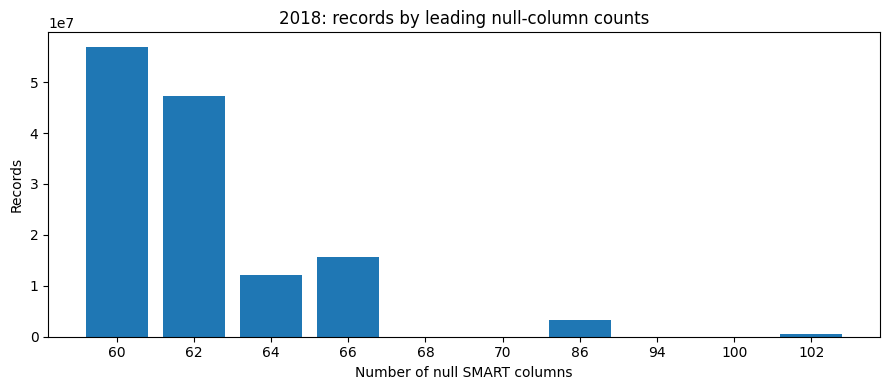

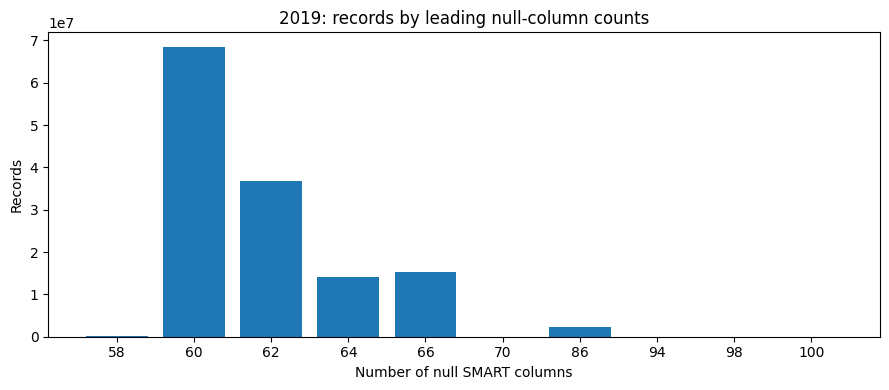

In [6]:
for year,p in [(2018,p18),(2019,p19)]:
    d=p.groupby("NULL_COLUMN_COUNT").RECORD_COUNT.sum().sort_values(ascending=False).head(10).sort_index()
    plt.figure(figsize=(9,4))
    plt.bar(d.index.astype(str), d.values)
    plt.title(f"{year}: records by leading null-column counts")
    plt.xlabel("Number of null SMART columns")
    plt.ylabel("Records")
    plt.tight_layout()
    plt.show()

**Decision reproduced:** drop only the 34 columns belonging to the 17 attributes absent in both years from the shared modeling schema. Keep SMART 211 because it appears in 2019. Quarantine all-102-null rows instead of feeding them to value-based training.